In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 

np.random.seed(42)

n_users_ab = 3000

ab_users = [f"USER_AB_{1000 + i}" for i in range(n_users_ab)]

groups = np.random.choice(['A', 'B'], size=n_users_ab, p=[0.5, 0.5])

conversion_rates = {'A': 0.50, 'B': 0.56}

converted_cart = []

for group in groups:
    p = conversion_rates[group]
    is_converted = 1 if np.random.rand() < p else 0
    converted_cart.append(is_converted)

df_ab = pd.DataFrame({
    'user_id': ab_users,
    'group': groups,
    'converted_to_cart': converted_cart
})

ab_summary = df_ab.groupby('group').agg(
    total_users=('converted_to_cart', 'count'),
    converted_users=('converted_to_cart', 'sum'),
    conversion_rate=('converted_to_cart', 'mean')
).reset_index()

ab_summary['conversion_rate_%'] = (ab_summary['conversion_rate'] * 100).round(2)
ab_summary 








,group,total_users,converted_users,conversion_rate,conversion_rate_%
0,A,1485,730,0.491582,49.16
1,B,1515,867,0.572277,57.23


In [9]:
data_a = df_ab[df_ab['group'] == 'A']['converted_to_cart']
data_b = df_ab[df_ab['group'] == 'B']['converted_to_cart']

t_stat, p_value = stats.ttest_ind(data_a, data_b)

print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.8f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nРезультат СТАТИСТИЧЕСКИ ЗНАЧИМ (p-value < {alpha})!")
    print("Принимаем гипотезу Н1: Новый дизайн карточки товара действительно увеличивает конверсию.")
else:
    print(f"\nРезультат СТАТИСТИЧЕСКИ НЕЗНАЧИМ (p-value > {alpha})!")
    print("Отклонить нулевую гипотезу Н0 нельзя: разница может быть случайным шумом")

t-статистика: -4.4420
p-value: 0.00000924

Результат СТАТИСТИЧЕСКИ ЗНАЧИМ (p-value < 0.05)!
Принимаем гипотезу Н1: Новый дизайн карточки товара действительно увеличивает конверсию.


In [10]:
mean_a = ab_summary.loc[ab_summary['group'] == 'A', 'conversion_rate'].values[0]
mean_b = ab_summary.loc[ab_summary['group'] == 'B', 'conversion_rate'].values[0]

n_a = ab_summary.loc[ab_summary['group'] == 'A', 'total_users'].values[0]
n_b = ab_summary.loc[ab_summary['group'] == 'B', 'total_users'].values[0]

diff = mean_b - mean_a 

se = np.sqrt((mean_a * (1 - mean_a) / n_a) + (mean_b * (1 - mean_b) / n_b))

z_score = stats.norm.ppf(0.975)

margin_of_error = z_score * se 

ci_lower = (diff - margin_of_error) * 100
ci_upper = (diff + margin_of_error) * 100

print(f"Абсолютный прирост конверсии (B - A): {diff * 100:.2f}%")
print(f"95%-й доверительный интервал для прироста: [{ci_lower:.2f}%, {ci_upper:.2f}%]")

Абсолютный прирост конверсии (B - A): 8.07%
95%-й доверительный интервал для прироста: [4.51%, 11.63%]


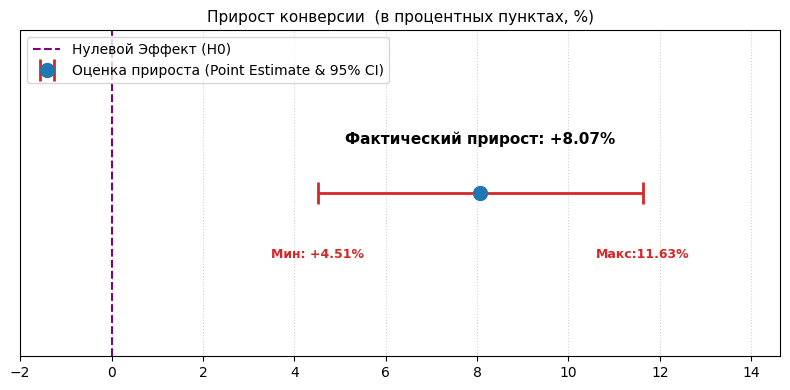

In [19]:
plt.close('all')
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    x=diff * 100,
    y=0,
    xerr=margin_of_error * 100,
    fmt='o',
    color='#1f77b4',
    ecolor='#d62728',
    elinewidth=2,
    capsize=8,
    capthick=2,
    markersize=10,
    label='Оценка прироста (Point Estimate & 95% CI)'
)

ax.axvline(x=0, color='purple', linestyle='--', linewidth=1.5, label='Нулевой Эффект (Н0)')

ax.set_title('95% Доверительный интервал прироста конверсии (Lift: B vs A)', fontsize=13, fontweight='bold', pad=15)
ax.set_title('Прирост конверсии  (в процентных пунктах, %)', fontsize=11)
ax.set_yticks([])

ax.text(diff * 100, 0.15, f"Фактический прирост: +{diff * 100:.2f}%", ha='center', fontsize='11', fontweight='bold')
ax.text(ci_lower, -0.2, f"Мин: +{ci_lower:.2f}%", ha='center', fontsize=9, color='#d62728', fontweight='bold')
ax.text(ci_upper, -0.2, f"Макс:{ci_upper:.2f}%", ha='center', fontsize=9, color='#d62728', fontweight='bold')

ax.set_xlim(min(-2, ci_lower - 2), ci_upper + 3)
ax.set_ylim(-0.5, 0.5)
ax.grid(axis='x', linestyle=':', alpha=0.6)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [20]:
average_order_value = 2500

ab_summary['total_revenue'] = ab_summary['converted_users'] * average_order_value

ab_summary['arpu'] = (ab_summary['total_revenue'] / ab_summary['total_users']).round(2)

arpu_a = ab_summary.loc[ab_summary['group'] == 'A', 'arpu'].values[0]
arpu_b = ab_summary.loc[ab_summary['group'] == 'B', 'arpu'].values[0]

arpu_lift = arpu_b - arpu_a
arpu_lift_pct = ((arpu_b - arpu_a) / arpu_a) * 100

print(f" ARPU группы А (Контроль): {arpu_a:.2f} сом.")
print(f" ARPU группы B (Тест): {arpu_b:.2f} сом.")
print(f" Дополнительный доход с КАЖДОГО пользователя: +{arpu_lift:.2f} сом. (+{arpu_lift_pct:.2f}%)")

ab_summary[['group', 'total_users', 'converted_users', 'conversion_rate_%', 'total_revenue', 'arpu']]

 ARPU группы А (Контроль): 1228.96 сом.
 ARPU группы B (Тест): 1430.69 сом.
 Дополнительный доход с КАЖДОГО пользователя: +201.73 сом. (+16.41%)


,group,total_users,converted_users,conversion_rate_%,total_revenue,arpu
0,A,1485,730,49.16,1825000,1228.96
1,B,1515,867,57.23,2167500,1430.69


In [22]:
print("="*60)
print("ФИНАЛНЫЙ ОТЧЕТ ПО A/B-ТЕСТУ (EXECUTIVE SUMMARY)")
print("="*60)
print(f"1. РЕЗУЛЬТАТ КОНВЕРСИИ:")
print(f" * Группа А (Control): {ab_summary.loc[0, 'conversion_rate_%']:.2f}%")
print(f" * Группа B (Test): {ab_summary.loc[1, 'conversion_rate_%']:.2f}%")
print(f" * Фактический Lift: +{diff * 100:.2f}% (p-value = {p_value:.8f})")
print(f"  * 95% Доверительный интервал: [{ci_lower:.2f}%, {ci_upper:.2f}%]")
print("-" * 60)
print(f"2. ФИНАНСОВЫЙ ЭФФЕКТ (при среднем чеке {average_order_value} сом):")
print(f" * ARPU Группы A: {arpu_a:.2f} сом.")
print(f" * ARPU Группы B: {arpu_b:.2f} сом.")
print(f" * Прирост ARPU:  +{arpu_lift:.2f} сом. (+{arpu_lift_pct:.2f}%)")
print("-" * 60)
print("3. БИЗНЕС-РЕКОМЕНДАЦИЯ:")
if p_value < 0.05 and ci_lower > 0:
    print("РЕКОМЕНДОВАНО К РАСКАТКЕ (Rollout to 100%).")
    print("Различия статистически значимы. Новый продукт увеличивает")
    print("конверсию и принесет минимум +4.51% к приросту на всей популяции.")
else:
    print("НЕ РЕКОМЕНДОВАНО. Эффект не доказан статистически.")
print("="*60)

ФИНАЛНЫЙ ОТЧЕТ ПО A/B-ТЕСТУ (EXECUTIVE SUMMARY)
1. РЕЗУЛЬТАТ КОНВЕРСИИ:
 * Группа А (Control): 49.16%
 * Группа B (Test): 57.23%
 * Фактический Lift: +8.07% (p-value = 0.00000924)
  * 95% Доверительный интервал: [4.51%, 11.63%]
------------------------------------------------------------
2. ФИНАНСОВЫЙ ЭФФЕКТ (при среднем чеке 2500 сом):
 * ARPU Группы A: 1228.96 сом.
 * ARPU Группы B: 1430.69 сом.
 * Прирост ARPU:  +201.73 сом. (+16.41%)
------------------------------------------------------------
3. БИЗНЕС-РЕКОМЕНДАЦИЯ:
РЕКОМЕНДОВАНО К РАСКАТКЕ (Rollout to 100%).
Различия статистически значимы. Новый продукт увеличивает
конверсию и принесет минимум +4.51% к приросту на всей популяции.
